In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
import time
import numpy as np
from stable_baselines3 import SAC
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '../'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from BESSOptimisation.src.utils import TimeTrackingCallback
from BESSOptimisation.src.rl.dayahead_agent import BESSEnv

# PPO

--- Loading model: ../models/bess_ppo_lookahead_normalized ---


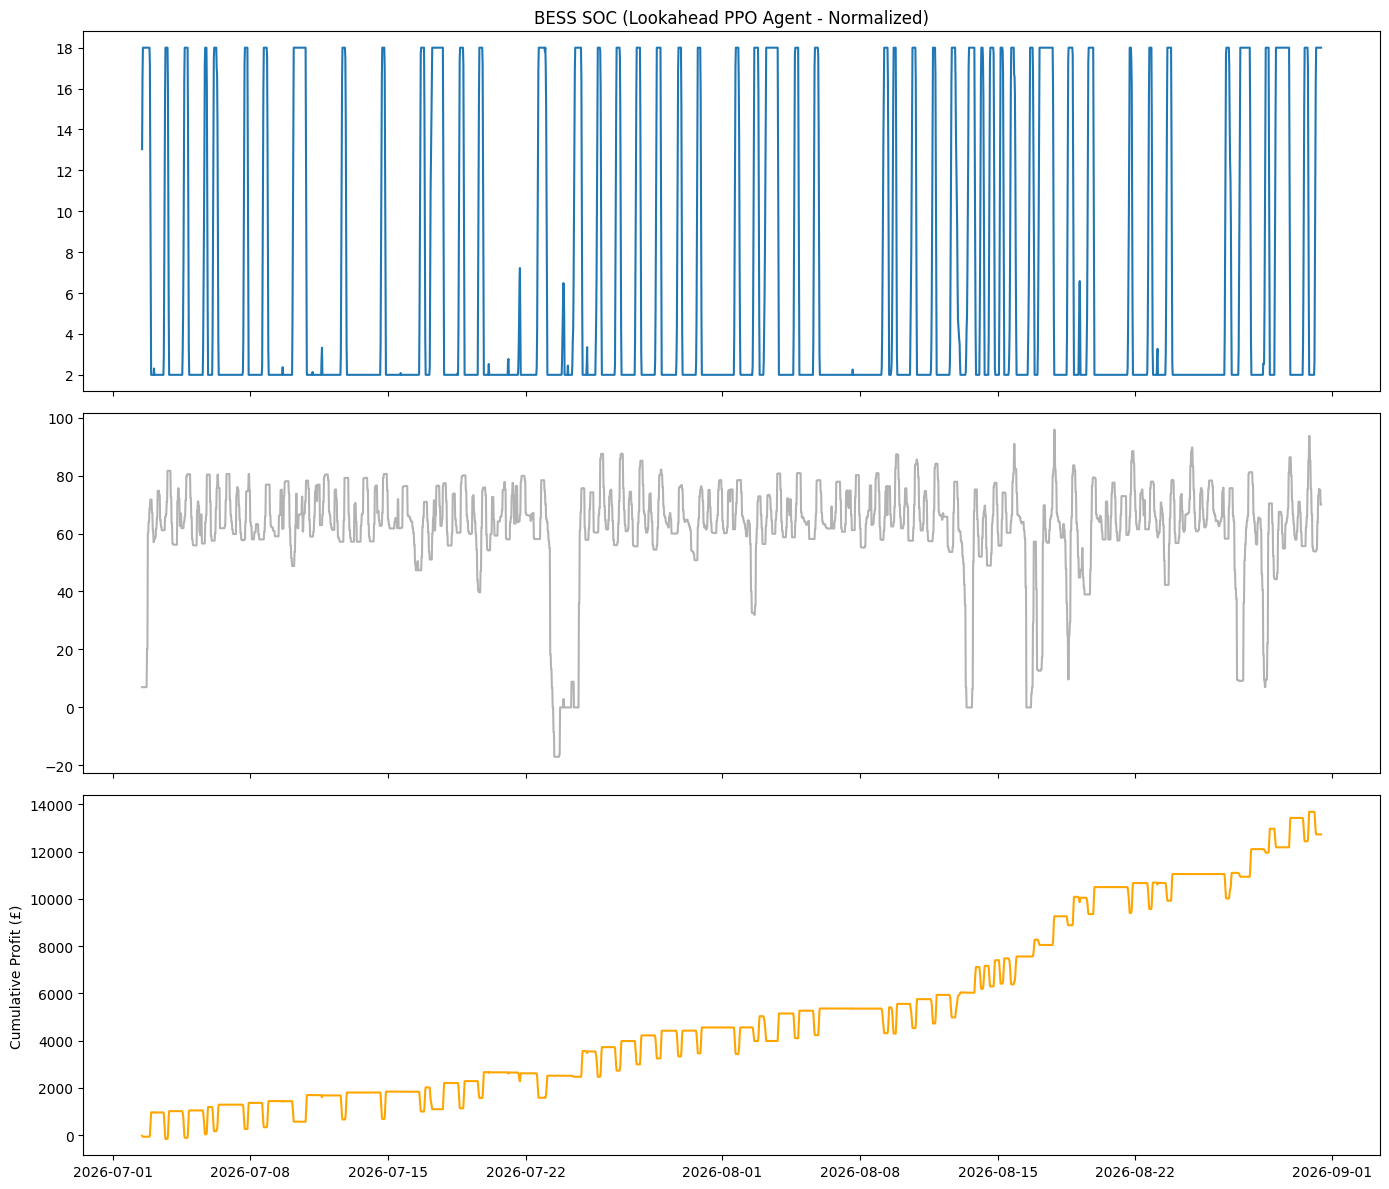

Total Net Profit: £7,496.73
Final SOH: 99.19%


In [11]:
# Configuration
MODEL_NAME = "../models/bess_ppo_lookahead_normalized"
VEC_NORM_PATH = "../models/vec_normalize_ppo.pkl"
TRAIN_STEPS = 500000
DATA_PATH = '../data/GBCentralAllComplete_Prices.csv'

battery_params = {
    'time_interval': 0.5, 
    'max_power': 10, 
    'capacity': 20, 
    'rte': 0.9, 
    'soc_min_factor': 0.1, 
    'soc_max_factor': 0.9,
    'deg_per_mwh': 0.00001
}

# Data Preparation
prices_df = pd.read_csv(DATA_PATH, index_col='Date', parse_dates=True)
prices_df = prices_df[['DayAhead']]
train_df = prices_df.iloc[:8760]
eval_df = prices_df.iloc[8760:11640]

#environment setup
env = DummyVecEnv([lambda: BESSEnv(train_df, battery_params)])
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

policy_kwargs = dict(net_arch=[256, 256])

#training
if os.path.exists(f"{MODEL_NAME}.zip"):
    print(f"--- Loading model: {MODEL_NAME} ---")
    model = PPO.load(MODEL_NAME, env=env)
    env = VecNormalize.load(VEC_NORM_PATH, env)
else:
    print(f"--- Training model for {TRAIN_STEPS} steps ---")
    model = PPO("MlpPolicy", env, 
                gamma=0.999,
                ent_coef=0.01,
                verbose=1, 
                policy_kwargs=policy_kwargs)

    # Initialise the timer callback
    timer_callback = TimeTrackingCallback()
    
    # Pass the callback to the learn method
    model.learn(total_timesteps=TRAIN_STEPS, callback=timer_callback)
    
    model.save(MODEL_NAME)
    env.save(VEC_NORM_PATH)

# evaluation
eval_env = DummyVecEnv([lambda: BESSEnv(eval_df, battery_params)])
eval_env = VecNormalize.load(VEC_NORM_PATH, eval_env)
eval_env.training = False 
eval_env.norm_reward = False 

obs = eval_env.reset()

for _ in range(len(eval_df) - 2):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = eval_env.step(action)
    if done[0]: break

# Plotting and Results
res_df = pd.DataFrame(eval_env.envs[0].history)
res_df.index = eval_df.index[:len(res_df)]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
ax1.plot(res_df.index, res_df['SOC'], color='tab:blue')
ax1.set_title("BESS SOC (Lookahead PPO Agent - Normalized)")
ax2.plot(res_df.index, eval_df['DayAhead'].iloc[:len(res_df)], color='black', alpha=0.3)
ax3.plot(res_df.index, res_df['Revenue'].cumsum(), color='orange')
ax3.set_ylabel("Cumulative Profit (£)")

plt.tight_layout()
plt.show()

print(f"Total Net Profit: £{res_df['Revenue'].sum() - res_df['Penalty'].sum():,.2f}")
print(f"Final SOH: {res_df['SOH'].iloc[-1]:.2%}")

# DQN 

--- Loading model: ../models/bess_dqn_original_competitive ---


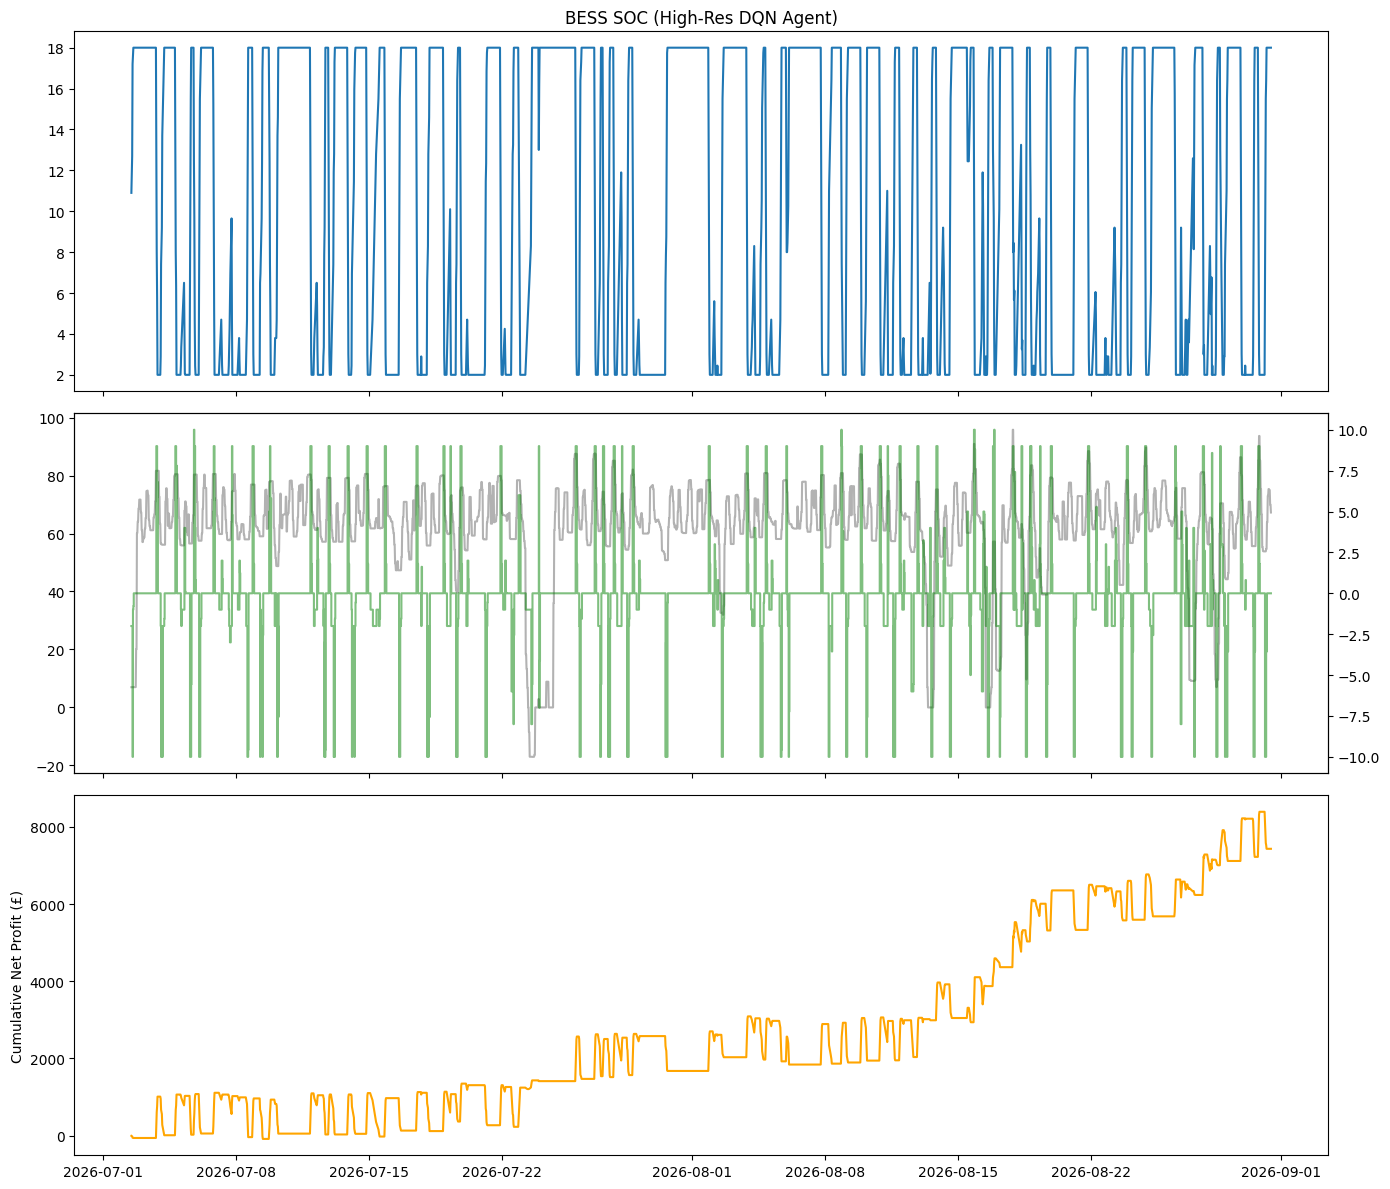

Total Net Profit: £7,432.32
Final SOH: 99.12%


In [14]:

class DiscreteBESSWrapper(gym.ActionWrapper):
    """
    Converts the continuous action space of the BESS environment into a discrete one.
    """
    def __init__(self, env, num_bins=21):
        """
        Initialise the discrete action wrapper.
        """
        super().__init__(env)
        self.action_space = spaces.Discrete(num_bins) #divides the action space into 21 bins
        self.action_map = np.linspace(-1.0, 1.0, num_bins)

    def action(self, act):
        """
        Map the discrete action back to the continuous action space.
        """
        return np.array([self.action_map[act]], dtype=np.float32)

class BESSEnv(gym.Env):
    """
    Custom Reinforcement Learning Environment for BESS Arbitrage (Day Ahead Market Only)
    """
    def __init__(self, df, battery_params):
        """
        Initialise the BESS environment.
        """
        super(BESSEnv, self).__init__()
        self.df = df
        self.lookahead_steps = 48  
        self.dt = battery_params.get('time_interval', 0.5)
        self.capacity = battery_params.get('capacity', 20)
        self.p_max = battery_params.get('max_power', 10)
        self.rte = battery_params.get('rte', 0.9)
        self.deg_per_mwh = battery_params.get('deg_per_mwh', 0.00001)
        self.soc_min = battery_params.get('soc_min_factor', 0.1) * self.capacity
        self.soc_max = battery_params.get('soc_max_factor', 0.9) * self.capacity
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(2 + self.lookahead_steps,), dtype=np.float32
        )
        self.history = []
        self.eval_history = []
        self.reset()

    def reset(self, seed=None, options=None):
        """
        Reset the environment to an initial state.
        """
        super().reset(seed=seed)
        self.current_step = 0
        self.soc = self.capacity * 0.5
        self.soh = 1.0
        if hasattr(self, 'history') and len(self.history) > 0:
            self.eval_history = self.history.copy()
        self.history = []
        return self._get_obs(), {}

    def _get_obs(self):
        """
        Get the current observation.
        """
        normalized_soc = (self.soc - self.soc_min) / (self.soc_max - self.soc_min)
        soc_obs = np.array([normalized_soc], dtype=np.float32)
        current_time = self.df.index[self.current_step]
        hour_obs = np.array([current_time.hour / 23.0], dtype=np.float32)
        prices = self.df['DayAhead'].values
        end_idx = self.current_step + self.lookahead_steps
        if end_idx <= len(prices):
            price_window = prices[self.current_step : end_idx]
        else:
            actual_prices = prices[self.current_step:]
            padding = np.full(self.lookahead_steps - len(actual_prices), prices[-1])
            price_window = np.concatenate([actual_prices, padding])
        return np.concatenate([soc_obs, hour_obs, price_window]).astype(np.float32)

    def step(self, action):
        """
        Execute one time step within the environment.
        """
        price = self.df.iloc[self.current_step]['DayAhead']
        power = action[0] * self.p_max
        if power < 0:
            energy_delta = -power * self.rte * self.dt
        else: 
            energy_delta = - (power / self.rte) * self.dt
        new_soc = np.clip(self.soc + energy_delta, self.soc_min, self.soc_max)
        actual_energy_delta = new_soc - self.soc
        if actual_energy_delta > 0: 
            actual_power = -(actual_energy_delta / (self.rte * self.dt))
        else: 
            actual_power = -(actual_energy_delta * self.rte / self.dt)
        self.soc = new_soc
        revenue = actual_power * price * self.dt
        throughput = abs(actual_energy_delta) if actual_energy_delta < 0 else 0
        penalty = throughput * 6.50
        reward = revenue - penalty
        self.soh -= throughput * self.deg_per_mwh
        self.history.append({
            'SOC': self.soc,
            'Power_DayAhead': actual_power,
            'Revenue': revenue,
            'Penalty': penalty,
            'Throughput': throughput,
            'SOH': self.soh
        })
        self.current_step += 1
        done = self.current_step >= len(self.df) - 1
        return self._get_obs(), reward, done, False, {}



MODEL_NAME = "../models/bess_dqn_original_competitive"
VEC_NORM_PATH = "../models/vec_normalize_dqn_original.pkl"
TRAIN_STEPS = 500000 
DATA_PATH = '../data/GBCentralAllComplete_Prices.csv'

battery_params = {
    'time_interval': 0.5, 
    'max_power': 10, 
    'capacity': 20, 
    'rte': 0.9, 
    'soc_min_factor': 0.1, 
    'soc_max_factor': 0.9,
    'deg_per_mwh': 0.00001
}

# Data loading and preprocessing
prices_df = pd.read_csv(DATA_PATH, index_col='Date', parse_dates=True)
prices_df = prices_df[['DayAhead']]
train_df = prices_df.iloc[:8760]
eval_df = prices_df.iloc[8760:11640]

# setting up environment
env = DummyVecEnv([lambda: DiscreteBESSWrapper(BESSEnv(train_df, battery_params), num_bins=21)])
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.) #scales the input data for better learning

policy_kwargs = dict(net_arch=[256, 256]) #DQN with 2 hidden layers of 256 neurons each


if os.path.exists(f"{MODEL_NAME}.zip"):
    print(f"--- Loading model: {MODEL_NAME} ---")
    model = DQN.load(MODEL_NAME, env=env)
    env = VecNormalize.load(VEC_NORM_PATH, env)
else:
    print(f"--- Training model for {TRAIN_STEPS} steps ---")
    model = DQN("MlpPolicy", env, 
                gamma=0.999, #high value so agent prioritises long term rewards
                exploration_fraction=0.5, 
                exploration_final_eps=0.05, 
                verbose=1, 
                policy_kwargs=policy_kwargs)
    
    # Initialise and apply the timer callback
    timer_callback = TimeTrackingCallback()
    model.learn(total_timesteps=TRAIN_STEPS, callback=timer_callback)
    
    model.save(MODEL_NAME)
    env.save(VEC_NORM_PATH)

# Evaluating the model
eval_env = DummyVecEnv([lambda: DiscreteBESSWrapper(BESSEnv(eval_df, battery_params), num_bins=21)])
eval_env = VecNormalize.load(VEC_NORM_PATH, eval_env)
eval_env.training = False 
eval_env.norm_reward = False 

obs = eval_env.reset()

for _ in range(len(eval_df) - 1):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = eval_env.step(action)
    if done[0]: break

# plotting
res_df = pd.DataFrame(eval_env.envs[0].env.eval_history)
res_df.index = eval_df.index[:len(res_df)]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
ax1.plot(res_df.index, res_df['SOC'], color='tab:blue')
ax1.set_title("BESS SOC (High-Res DQN Agent)")
ax2.plot(res_df.index, eval_df['DayAhead'].iloc[:len(res_df)], color='black', alpha=0.3)
ax2_twin = ax2.twinx()
ax2_twin.step(res_df.index, res_df['Power_DayAhead'], where='post', color='green', alpha=0.5)

net_profit = res_df['Revenue'] - res_df['Penalty']
ax3.plot(res_df.index, net_profit.cumsum(), color='orange')
ax3.set_ylabel("Cumulative Net Profit (£)")

plt.tight_layout()
plt.show()

print(f"Total Net Profit: £{net_profit.sum():,.2f}")
print(f"Final SOH: {res_df['SOH'].iloc[-1]:.2%}")

# SAC

--- Loading model: ../models/bess_sac_lookahead_normalized ---


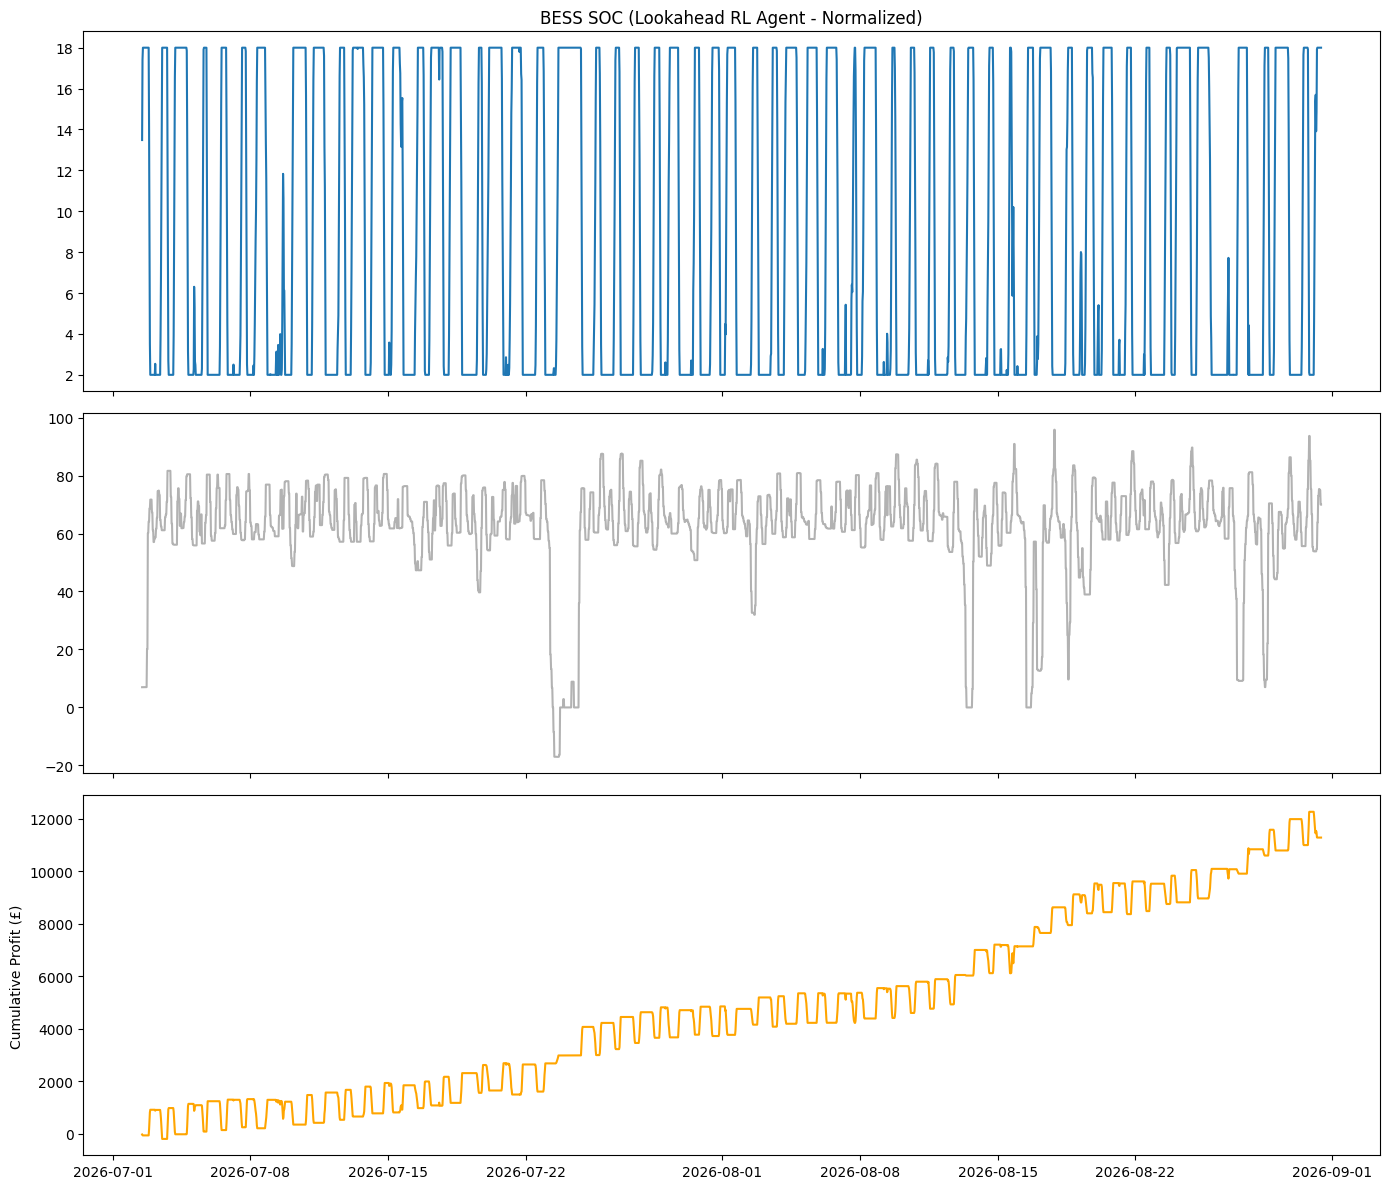

Total Net Profit: £4,905.78
Final SOH: 99.02%


In [17]:
#configuration
MODEL_NAME = "../models/bess_sac_lookahead_normalized"
VEC_NORM_PATH = "../models/vec_normalize.pkl"
TRAIN_STEPS = 500000
DATA_PATH = '../data/GBCentralAllComplete_Prices.csv'

battery_params = {
    'time_interval': 0.5, 
    'max_power': 10, 
    'capacity': 20, 
    'rte': 0.9, 
    'soc_min_factor': 0.1, 
    'soc_max_factor': 0.9,
    'deg_per_mwh': 0.00001
}

# Load Data
prices_df = pd.read_csv(DATA_PATH, index_col='Date', parse_dates=True)
prices_df = prices_df[['DayAhead']]

train_df = prices_df.iloc[:8760] 
eval_df = prices_df.iloc[8760:11640] 

#environment setup
env = DummyVecEnv([lambda: BESSEnv(train_df, battery_params)])
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

policy_kwargs = dict(net_arch=[256, 256])

# training
if os.path.exists(f"{MODEL_NAME}.zip"):
    print(f"--- Loading model: {MODEL_NAME} ---")
    model = SAC.load(MODEL_NAME, env=env)
    env = VecNormalize.load(VEC_NORM_PATH, env)
else:
    print(f"--- Training model for {TRAIN_STEPS} steps ---")
    model = SAC("MlpPolicy", env, 
                gamma=0.999,
                verbose=1, 
                policy_kwargs=policy_kwargs,
                ent_coef='auto')

    # initialise the timer callback
    timer_callback = TimeTrackingCallback()
    model.learn(total_timesteps=TRAIN_STEPS, callback=timer_callback)
    
    model.save(MODEL_NAME)
    env.save(VEC_NORM_PATH)

# evaluation
eval_env = DummyVecEnv([lambda: BESSEnv(eval_df, battery_params)])
eval_env = VecNormalize.load(VEC_NORM_PATH, eval_env)
eval_env.training = False 
eval_env.norm_reward = False 

obs = eval_env.reset()

for _ in range(len(eval_df) - 2):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = eval_env.step(action)
    if done[0]: break

# plotting
res_df = pd.DataFrame(eval_env.envs[0].history)
res_df.index = eval_df.index[:len(res_df)]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
ax1.plot(res_df.index, res_df['SOC'], color='tab:blue')
ax1.set_title("BESS SOC (Lookahead RL Agent - Normalized)")
ax2.plot(res_df.index, eval_df['DayAhead'].iloc[:len(res_df)], color='black', alpha=0.3)
ax3.plot(res_df.index, res_df['Revenue'].cumsum(), color='orange')
ax3.set_ylabel("Cumulative Profit (£)")

plt.tight_layout()
plt.show()

print(f"Total Net Profit: £{res_df['Revenue'].sum() - res_df['Penalty'].sum():,.2f}")
print(f"Final SOH: {res_df['SOH'].iloc[-1]:.2%}")